In [25]:
import os

import numpy as np
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt

from src.dataset import SatelliteDataset, get_eval_transforms, denormalize_images

%load_ext autoreload
%autoreload 2

if not os.path.exists('./images/'):
    os.mkdir('./images/')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
# images are printed as presented to the model during training
loader = DataLoader(
    dataset=SatelliteDataset(file="artifacts/train.csv", transforms=get_eval_transforms()),
    shuffle=True,
    batch_size=16,
)

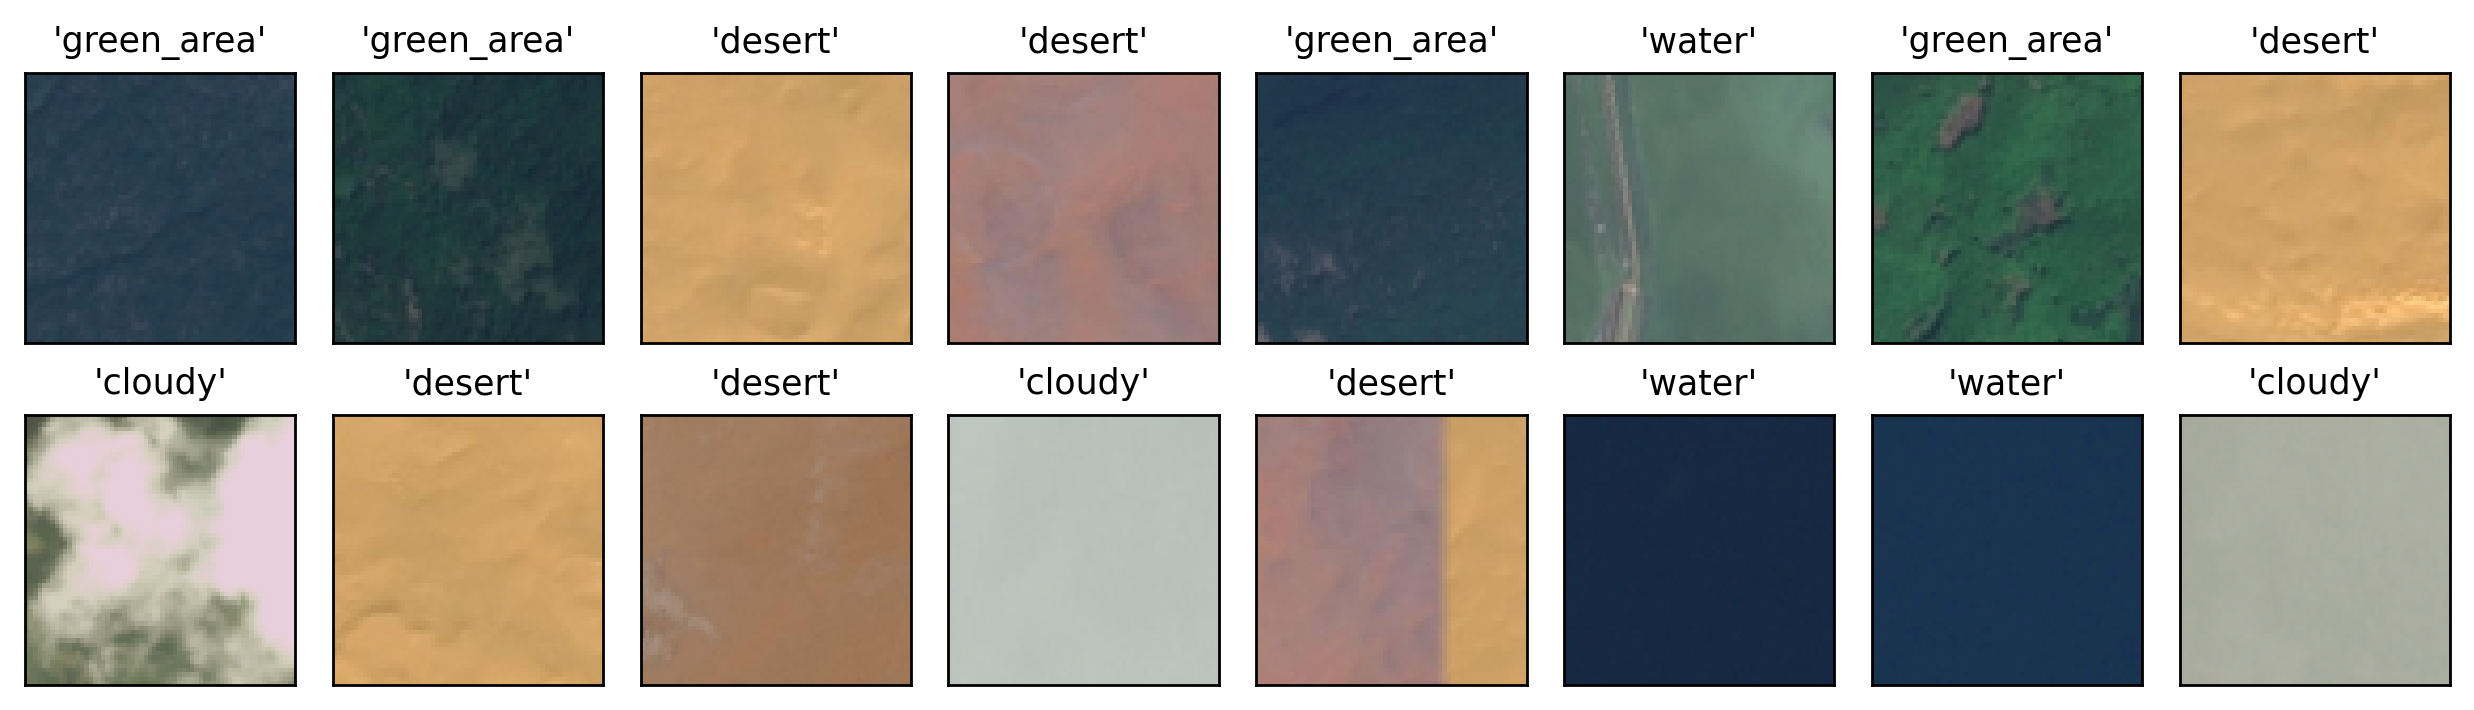

In [65]:
images, labels = next(iter(loader))
fig, axs = plt.subplots(2, len(images) // 2, dpi=250, figsize=(10, 3))

for ax, im, lab in zip(axs.flatten(), images, labels):
    im = denormalize_images(im)
    im = im[0].permute(1, 2, 0)
    ax.imshow(im)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"\'{list(SatelliteDataset.CLASSES.keys())[lab.item()]}\'", fontsize=10)

fig.tight_layout()
fig.savefig(os.path.join('images', 'training_samples.png'), bbox_inches='tight')